**Autor:** PEDRO HENRIQUE BENICIO DE OLIVEIRA — **RGM:** 33602697

# Entrega 2 — Detecção de Duplicatas Semânticas
Implementamos `detectar_duplicatas(textos, limiar=0.85)` (em `ouvidoria_utils.py`), avaliamos com o
gabarito (`duplicatas_reais.json`) e discutimos a escolha do limiar.

In [1]:
import os, warnings
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import ouvidoria_utils as u

df = u.carregar_manifestacoes()
textos = df["texto"].tolist()
idx = {i: k for k, i in enumerate(df["id"])}   # id -> posição na matriz
print(f"{len(df)} manifestações | categorias: {df.categoria_oficial.value_counts().to_dict()}")
df.head()
import inspect

40 manifestações | categorias: {'meio ambiente': 9, 'infraestrutura': 8, 'saúde': 8, 'educação': 8, 'segurança': 7}


## 1. A função

In [2]:
print(inspect.getsource(u.detectar_duplicatas))

def detectar_duplicatas(textos, limiar: float = 0.85, embeddings=None, modelo=None,
                        ids=None) -> list:
    """Retorna [(i, j, similaridade), ...] com i<j e similaridade >= limiar, ordenado do maior p/ menor.

    Recebe a lista de manifestações (textos). Se `embeddings` não for informado, gera com `modelo`
    (ou com o modelo padrão). `ids` opcional troca os índices por identificadores (ex.: 'M003')."""
    if embeddings is None:
        modelo = modelo or carregar_modelo()
        embeddings = codificar(modelo, textos)
    sim = cosine_similarity(embeddings)
    rotulos = ids if ids is not None else list(range(len(textos)))
    pares = [(rotulos[i], rotulos[j], float(sim[i, j]))
             for i in range(len(textos)) for j in range(i + 1, len(textos)) if sim[i, j] >= limiar]
    return sorted(pares, key=lambda p: -p[2])



## 2. Embeddings e matriz de similaridade completa

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4558.95it/s]

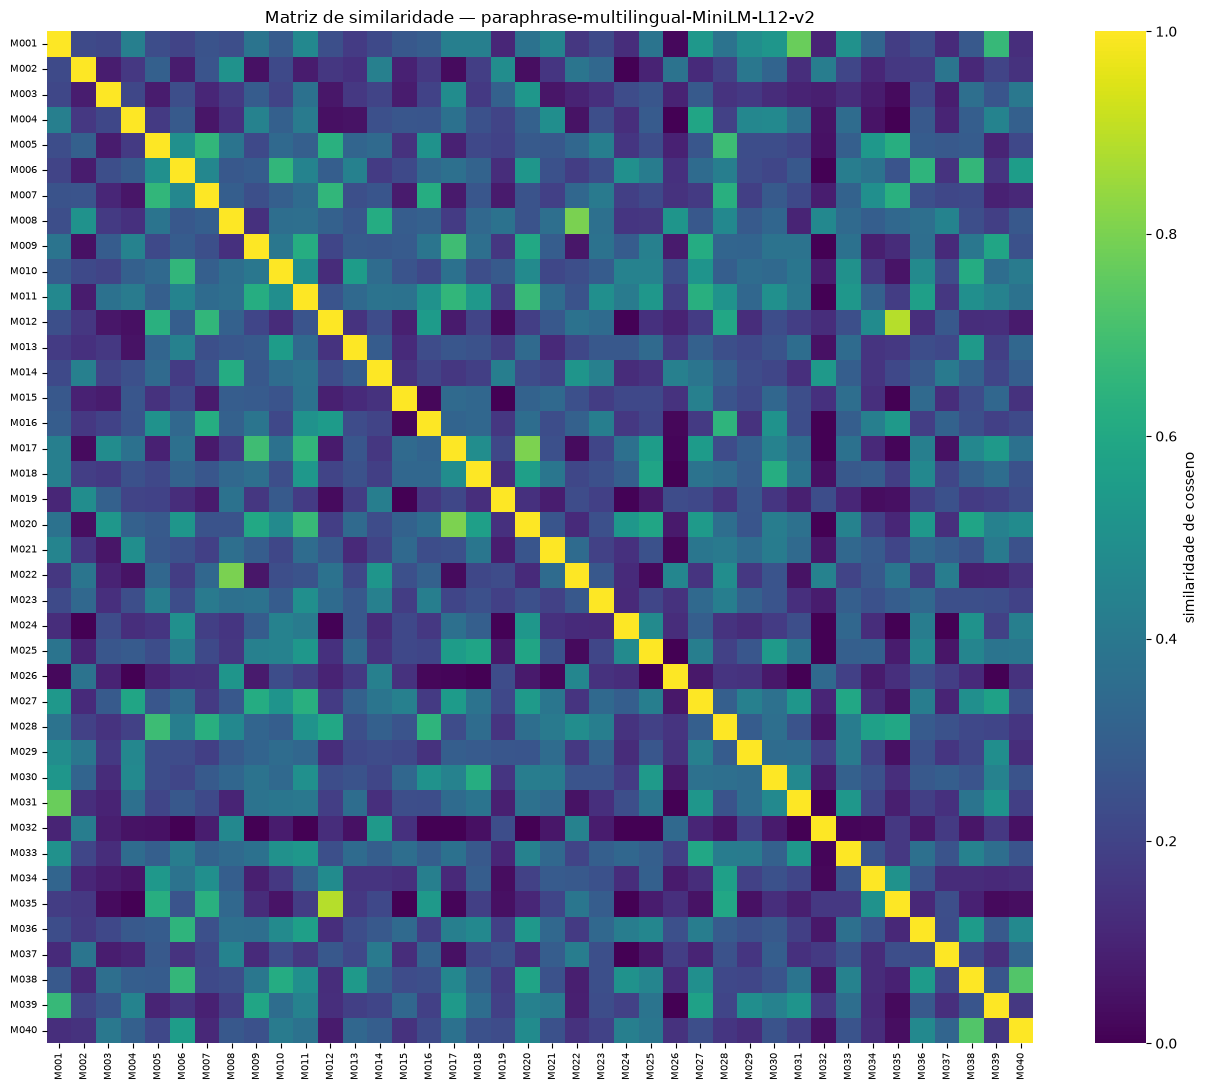

In [3]:
NOME = "paraphrase-multilingual-MiniLM-L12-v2"
modelo = u.carregar_modelo(NOME)
emb = u.codificar(modelo, textos, NOME)
S = u.matriz_similaridade(emb)

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(S, xticklabels=df.id, yticklabels=df.id, cmap="viridis", vmin=0, vmax=1, ax=ax,
            cbar_kws={"label": "similaridade de cosseno"})
ax.set_title(f"Matriz de similaridade — {NOME}")
plt.xticks(fontsize=7, rotation=90); plt.yticks(fontsize=7); plt.tight_layout(); plt.show()

## 3. Pares duplicados com o limiar padrão (0,85)

In [4]:
pares85 = u.detectar_duplicatas(textos, limiar=0.85, embeddings=emb, ids=df.id.tolist())
pd.DataFrame(pares85, columns=["id_a", "id_b", "similaridade"]) if pares85 else "Nenhum par ≥ 0,85"

,id_a,id_b,similaridade
0,M012,M035,0.890079


## 4. Justificando o limiar
Não há um limiar universal: depende do modelo e do custo de errar. Varremos vários limiares e comparamos com o
gabarito (precisão, revocação e F1). Também avaliamos um **limiar dinâmico** pelo percentil 99 da distribuição
(cerca de 8 dos 780 pares).

In [5]:
real = u.carregar_duplicatas_reais()
print("Duplicatas reais (gabarito):", sorted(real))

def avaliar(limiar):
    pred = {tuple(sorted((a, b))) for a, b, _ in u.detectar_duplicatas(textos, limiar, emb, ids=df.id.tolist())}
    tp, fp, fn = len(pred & real), len(pred - real), len(real - pred)
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * p * r / (p + r) if p + r else 0.0
    return dict(limiar=round(limiar, 3), previstos=len(pred), VP=tp, FP=fp, FN=fn, precisão=p, revocação=r, F1=f1), pred

iu = np.triu_indices(len(df), 1)
p99 = float(np.percentile(S[iu], 99))
limiares = [0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60, round(p99, 3)]
varredura = pd.DataFrame([avaliar(l)[0] for l in limiares]).sort_values("limiar", ascending=False)
print(f"Percentil 99 da distribuição = {p99:.3f}")
varredura.style.format({"precisão": "{:.2f}", "revocação": "{:.2f}", "F1": "{:.2f}"})

Duplicatas reais (gabarito): [('M003', 'M017'), ('M008', 'M022'), ('M012', 'M035')]
Percentil 99 da distribuição = 0.672


,limiar,previstos,VP,FP,FN,precisão,revocação,F1
0,0.950000,0,0,0,3,0.00,0.00,0.00
1,0.900000,0,0,0,3,0.00,0.00,0.00
2,0.850000,1,1,0,2,1.00,0.33,0.50
3,0.800000,2,1,1,2,0.50,0.33,0.40
4,0.750000,4,2,2,1,0.50,0.67,0.57
5,0.700000,5,2,3,1,0.40,0.67,0.50
8,0.672000,8,2,6,1,0.25,0.67,0.36
6,0.650000,16,2,14,1,0.12,0.67,0.21
7,0.600000,28,2,26,1,0.07,0.67,0.13


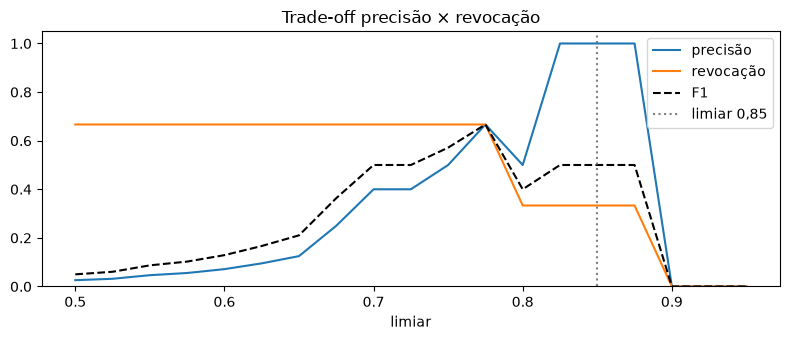

Melhor F1 = 0.67 com limiar ≈ 0.775


In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
grade = np.arange(0.5, 0.96, 0.025)
res = pd.DataFrame([avaliar(l)[0] for l in grade])
ax.plot(res.limiar, res["precisão"], label="precisão"); ax.plot(res.limiar, res["revocação"], label="revocação")
ax.plot(res.limiar, res["F1"], "k--", label="F1"); ax.axvline(0.85, color="gray", ls=":", label="limiar 0,85")
ax.set(xlabel="limiar", ylim=(0, 1.05), title="Trade-off precisão × revocação"); ax.legend(); plt.tight_layout(); plt.show()
melhor = res.loc[res.F1.idxmax()]
print(f"Melhor F1 = {melhor.F1:.2f} com limiar ≈ {melhor.limiar:.3f}")

## 5. Falsos positivos e falsos negativos (limiar 0,85 e limiar de melhor F1)

In [7]:
def relatorio(limiar):
    m, pred = avaliar(limiar)
    print(f"\n=== limiar {limiar:.3f} === VP={m['VP']} FP={m['FP']} FN={m['FN']}")
    for titulo, conj in [("Verdadeiros positivos", pred & real), ("FALSOS POSITIVOS", pred - real), ("FALSOS NEGATIVOS", real - pred)]:
        print(f"-- {titulo}")
        for a, b in sorted(conj):
            print(f"   {a} × {b}  (cos={S[idx[a], idx[b]]:.3f})\n      {a}: {textos[idx[a]][:110]}\n      {b}: {textos[idx[b]][:110]}")
relatorio(0.85)
relatorio(float(melhor.limiar))


=== limiar 0.850 === VP=1 FP=0 FN=2
-- Verdadeiros positivos
   M012 × M035  (cos=0.890)
      M012: Faltam professores de matemática na escola municipal do Centro. Os alunos do 8º ano estão sem essa matéria des
      M035: Os alunos do oitavo ano estão sem aula de matemática há meses porque a escola não tem professor contratado par
-- FALSOS POSITIVOS
-- FALSOS NEGATIVOS
   M003 × M017  (cos=0.484)
      M003: Existe um buraco enorme na Av. Brasil, na altura do número 1200, que já causou dois acidentes com motos. Preci
      M017: O asfalto da avenida principal está todo esburacado, os carros estão estragando pneus e suspensão.
   M008 × M022  (cos=0.797)
      M008: O posto de saúde do meu bairro está sem médico há mais de um mês e ninguém consegue marcar consulta.
      M022: Falta atendimento no PSF da comunidade. Não tem doutor e os agentes de saúde não aparecem.

=== limiar 0.775 === VP=2 FP=1 FN=1
-- Verdadeiros positivos
   M008 × M022  (cos=0.797)
      M008: O posto de saúde

## 6. Comparação entre modelos no mesmo gabarito

In [8]:
linhas = []
for nome in ["paraphrase-multilingual-MiniLM-L12-v2", "sentence-transformers/distiluse-base-multilingual-cased-v2", "intfloat/multilingual-e5-small"]:
    E = u.codificar(u.carregar_modelo(nome), textos, nome)
    M = u.matriz_similaridade(E)
    sim_real = [M[idx[a], idx[b]] for a, b in real]
    nao_dup = np.array([M[i, j] for i, j in zip(*iu) if (df.id[i], df.id[j]) not in real])
    linhas.append(dict(modelo=nome.split("/")[-1], sim_media_duplicatas=np.mean(sim_real),
                       sim_media_nao_dup=nao_dup.mean(), maior_nao_dup=nao_dup.max(),
                       menor_dup=min(sim_real), separável=min(sim_real) > nao_dup.max()))
pd.DataFrame(linhas).round(3)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4622.83it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2445.27it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4714.14it/s]

,modelo,sim_media_duplicatas,sim_media_nao_dup,maior_nao_dup,menor_dup,separável
0,paraphrase-multilingual-MiniLM-L12-v2,0.724,0.270,0.803,0.484,False
1,distiluse-base-multilingual-cased-v2,0.540,0.191,0.604,0.249,False
2,multilingual-e5-small,0.890,0.870,0.926,0.867,False


## 7. Análise e justificativa do limiar

**Gabarito:** 3 pares de duplicatas reais (M003×M017, M008×M022, M012×M035) em 780 pares possíveis.

| Limiar | Previstos | VP | FP | FN | Comentário |
|---|---|---|---|---|---|
| 0,85 (padrão) | 1 | 1 | 0 | 2 | precisão 100%, revocação 33% |
| ≈ 0,775 (melhor F1) | 3 | 2 | 1 | 1 | precisão 67%, revocação 67%, F1 = 0,67 |

* **Falsos negativos (0,85):** M008×M022 (cos = 0,797) — mesmo problema, mas a linguagem coloquial e a sigla "PSF" reduzem a
  similaridade — e M003×M017 (cos = 0,484), em que M003 traz informações extras (endereço, acidentes) e M017 usa outras palavras.
* **Falso positivo (0,775):** M017×M020 (cos = 0,803): ambas falam de asfalto ruim, mas M020 é uma reclamação longa e multi-assunto
  de outra rua. Mesmo *tema* ≠ mesma *manifestação*.
* **Não há limiar que separe perfeitamente** as classes com este modelo: a maior similaridade entre não duplicatas (0,80)
  supera a menor entre duplicatas (0,48). Com e5-small a situação é pior (ver tabela da seção 6) por causa da compressão de scores.
* **Limiar dinâmico:** o percentil 99 da distribuição (0,67 aqui) equivale a "os ~8 pares mais parecidos"; é útil para
  *ordenar candidatos* e se adapta a cada modelo, mas não sabe quantas duplicatas realmente existem.

**Decisão.** Manter **0,85** como limiar de *fusão automática* (nenhum falso positivo: não se descarta manifestação
legítima) e usar **0,75–0,78** como limiar de *sugestão para revisão humana*, aceitando alguns falsos positivos em troca de
revocação. Ressalva: com só 3 pares no gabarito as métricas são instáveis; em produção o limiar deve ser calibrado
em uma amostra maior rotulada por atendentes. Para melhorar M003×M017, seria possível pré-processar (normalizar
"Av."/"avenida"), comparar por *chunks* ou usar um modelo maior (ex.: bge-m3).
